In [2]:
import pygame
import math
import random
import numpy as np
from enum import Enum

# --- Game Constants ---
FIELD_WIDTH = 1200
FIELD_HEIGHT = 800
GOALKEEPER_SIZE = 30
ATTACKER_SIZE = 30
BALL_RADIUS = 10
GOAL_WIDTH = 180
GOAL_HEIGHT = 120
PENALTY_AREA_WIDTH = 165
PENALTY_AREA_HEIGHT = 400
SIX_YARD_WIDTH = 55
SIX_YARD_HEIGHT = 200
ATTACKER_SPEED = 4
CENTER_CIRCLE_RADIUS = 90
BALL_SPEED = 8
KICK_POWER = 12
BALL_FRICTION = 0.97

# --- Enhanced Colors ---
FIELD_GREEN = (34, 139, 34)
LINE_WHITE = (255, 255, 255)
GOAL_WHITE = (240, 240, 240)
GOALKEEPER_BLUE = (30, 144, 255)
ATTACKER_RED = (220, 20, 60)
BALL_WHITE = (255, 255, 255)
PREDICTION_PURPLE = (138, 43, 226)
GRASS_STRIPE_LIGHT = (40, 150, 40)
GRASS_STRIPE_DARK = (30, 130, 30)

class GoalkeeperState(Enum):
    IDLE = 0
    TRACKING = 1
    READY = 2
    DIVING = 3
    RECOVERING = 4

class DiveDirection(Enum):
    NONE = 0
    LEFT = 1
    RIGHT = 2
    DOWN = 3

# --- Initialize Pygame ---
pygame.init()
screen = pygame.display.set_mode((FIELD_WIDTH, FIELD_HEIGHT))
pygame.display.set_caption("Goalkeeper Training - Professional Edition")
clock = pygame.time.Clock()
font = pygame.font.Font(None, 24)
big_font = pygame.font.Font(None, 36)
small_font = pygame.font.Font(None, 18)

class Pitch:
    def __init__(self):
        self.width = FIELD_WIDTH
        self.height = FIELD_HEIGHT
        self.center_x = FIELD_WIDTH // 2
        self.center_y = FIELD_HEIGHT // 2
        
        self.goal_x = FIELD_WIDTH - 5
        self.goal_y = (FIELD_HEIGHT - GOAL_HEIGHT) // 2
        
        self.penalty_x = FIELD_WIDTH - PENALTY_AREA_WIDTH
        self.penalty_y = (FIELD_HEIGHT - PENALTY_AREA_HEIGHT) // 2
        
        self.six_yard_x = FIELD_WIDTH - SIX_YARD_WIDTH
        self.six_yard_y = (FIELD_HEIGHT - SIX_YARD_HEIGHT) // 2
        
        self.stripe_width = 60
        self.num_stripes = FIELD_WIDTH // self.stripe_width + 1
        
    def draw_grass_stripes(self, surface):
        """Draw realistic grass striping pattern"""
        for i in range(self.num_stripes):
            x = i * self.stripe_width
            color = GRASS_STRIPE_LIGHT if i % 2 == 0 else GRASS_STRIPE_DARK
            pygame.draw.rect(surface, color, (x, 0, self.stripe_width, FIELD_HEIGHT))
        
    def draw(self, surface):
        # Fill base and draw grass stripes
        surface.fill(FIELD_GREEN)
        self.draw_grass_stripes(surface)
        
        # Outer boundary with double line
        pygame.draw.rect(surface, LINE_WHITE, (0, 0, FIELD_WIDTH, FIELD_HEIGHT), 4)
        pygame.draw.rect(surface, LINE_WHITE, (3, 3, FIELD_WIDTH-6, FIELD_HEIGHT-6), 2)
        
        # Center line
        pygame.draw.line(surface, (200, 200, 200), 
                        (self.center_x+1, 1), (self.center_x+1, FIELD_HEIGHT-1), 2)
        pygame.draw.line(surface, LINE_WHITE, 
                        (self.center_x, 0), (self.center_x, FIELD_HEIGHT), 4)
        
        # Center circle
        pygame.draw.circle(surface, (200, 200, 200), 
                          (self.center_x+1, self.center_y+1), CENTER_CIRCLE_RADIUS, 3)
        pygame.draw.circle(surface, LINE_WHITE, 
                          (self.center_x, self.center_y), CENTER_CIRCLE_RADIUS, 4)
        
        # Center spot with glow
        pygame.draw.circle(surface, (255, 255, 200), (self.center_x, self.center_y), 8)
        pygame.draw.circle(surface, LINE_WHITE, (self.center_x, self.center_y), 6)
        
        # Right penalty area
        pygame.draw.rect(surface, LINE_WHITE,
                        (self.penalty_x, self.penalty_y, PENALTY_AREA_WIDTH, PENALTY_AREA_HEIGHT), 4)
        
        # Right six-yard box
        pygame.draw.rect(surface, LINE_WHITE,
                        (self.six_yard_x, self.six_yard_y, SIX_YARD_WIDTH, SIX_YARD_HEIGHT), 4)
        
        # Left penalty area
        pygame.draw.rect(surface, LINE_WHITE,
                        (0, self.penalty_y, PENALTY_AREA_WIDTH, PENALTY_AREA_HEIGHT), 4)
        
        # Left six-yard box
        pygame.draw.rect(surface, LINE_WHITE,
                        (0, self.six_yard_y, SIX_YARD_WIDTH, SIX_YARD_HEIGHT), 4)
        
        # Penalty spots with glow
        penalty_spot_x = FIELD_WIDTH - 110
        pygame.draw.circle(surface, (255, 255, 200), (penalty_spot_x, self.center_y), 7)
        pygame.draw.circle(surface, LINE_WHITE, (penalty_spot_x, self.center_y), 6)
        pygame.draw.circle(surface, (255, 255, 200), (110, self.center_y), 7)
        pygame.draw.circle(surface, LINE_WHITE, (110, self.center_y), 6)
        
        # Penalty arcs
        arc_rect = pygame.Rect(penalty_spot_x - 90, self.center_y - 90, 180, 180)
        pygame.draw.arc(surface, LINE_WHITE, arc_rect, math.pi/2, 3*math.pi/2, 4)
        
        arc_rect_left = pygame.Rect(110 - 90, self.center_y - 90, 180, 180)
        pygame.draw.arc(surface, LINE_WHITE, arc_rect_left, -math.pi/2, math.pi/2, 4)
        
        # Corner arcs
        corner_radius = 12
        pygame.draw.arc(surface, LINE_WHITE, 
                       (FIELD_WIDTH - corner_radius, -corner_radius, corner_radius*2, corner_radius*2),
                       math.pi, 3*math.pi/2, 4)
        pygame.draw.arc(surface, LINE_WHITE,
                       (FIELD_WIDTH - corner_radius, FIELD_HEIGHT - corner_radius, corner_radius*2, corner_radius*2),
                       math.pi/2, math.pi, 4)
        pygame.draw.arc(surface, LINE_WHITE,
                       (-corner_radius, -corner_radius, corner_radius*2, corner_radius*2),
                       0, math.pi/2, 4)
        pygame.draw.arc(surface, LINE_WHITE,
                       (-corner_radius, FIELD_HEIGHT - corner_radius, corner_radius*2, corner_radius*2),
                       3*math.pi/2, 2*math.pi, 4)
        
        # Corner flags
        self.draw_corner_flag(surface, FIELD_WIDTH - 8, 8)
        self.draw_corner_flag(surface, FIELD_WIDTH - 8, FIELD_HEIGHT - 8)
        self.draw_corner_flag(surface, 8, 8)
        self.draw_corner_flag(surface, 8, FIELD_HEIGHT - 8)
    
    def draw_corner_flag(self, surface, x, y):
        """Draw a small corner flag"""
        pygame.draw.line(surface, (200, 200, 200), (x, y), (x, y-20), 2)
        flag_points = [(x, y-20), (x+12, y-15), (x, y-10)]
        pygame.draw.polygon(surface, ATTACKER_RED, flag_points)

class Goal:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.width = 10
        self.height = GOAL_HEIGHT
        self.rect = pygame.Rect(x - 5, y, 15, GOAL_HEIGHT)
        
    def draw_net(self, surface):
        """Draw goal net pattern"""
        spacing = 8
        for i in range(0, self.height, spacing):
            pygame.draw.line(surface, (180, 180, 180), (self.x - 35, self.y + i), (self.x, self.y + i), 1)
        for i in range(-35, 0, spacing):
            pygame.draw.line(surface, (180, 180, 180), (self.x + i, self.y), (self.x + i, self.y + self.height), 1)
        
    def draw(self, surface):
        # Draw net first
        self.draw_net(surface)
        
        # Goal posts with 3D effect
        pygame.draw.rect(surface, (220, 220, 220), 
                        (self.x-2, self.y-2, self.width+4, 10))
        pygame.draw.rect(surface, GOAL_WHITE, 
                        (self.x, self.y, self.width, 8), 0)
        
        pygame.draw.rect(surface, (220, 220, 220),
                        (self.x-2, self.y + self.height - 6, self.width+4, 10))
        pygame.draw.rect(surface, GOAL_WHITE,
                        (self.x, self.y + self.height - 8, self.width, 8), 0)
        
        pygame.draw.rect(surface, (200, 200, 200),
                        (self.x-2, self.y-2, 10, self.height+4), 0)
        pygame.draw.rect(surface, GOAL_WHITE,
                        (self.x, self.y, 8, self.height), 0)
        
        # Highlight shine
        pygame.draw.rect(surface, (255, 255, 255),
                        (self.x+1, self.y+1, 2, 6), 0)
        
        # Goal line
        pygame.draw.line(surface, (200, 200, 200), 
                        (self.x - 6, self.y), (self.x - 6, self.y + self.height), 6)
        pygame.draw.line(surface, LINE_WHITE, 
                        (self.x - 5, self.y), (self.x - 5, self.y + self.height), 5)
    
    def check_goal(self, ball):
        return (ball.x >= self.x - 5 and 
                ball.y >= self.y and 
                ball.y <= self.y + self.height)

class Goalkeeper:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.home_x = x
        self.home_y = y
        self.size = GOALKEEPER_SIZE
        self.state = GoalkeeperState.IDLE
        self.dive_direction = DiveDirection.NONE
        self.dive_timer = 0
        self.dive_distance = 50
        
        self.target_x = x
        self.target_y = y
        self.movement_speed = 2.5
        
        self.threat_level = 0
        self.angle_coverage = 0
        self.optimal_position = (x, y)
        self.predicted_shot_angle = 0
        self.confidence = 0
        
    def calculate_optimal_position(self, attacker, ball):
        goal_center_x = FIELD_WIDTH - 25
        goal_center_y = FIELD_HEIGHT // 2
        
        threat_x = ball.x if abs(ball.dx) > 1 or abs(ball.dy) > 1 else attacker.x
        threat_y = ball.y if abs(ball.dx) > 1 or abs(ball.dy) > 1 else attacker.y
        
        top_post_y = goal_center_y - GOAL_HEIGHT // 2
        bottom_post_y = goal_center_y + GOAL_HEIGHT // 2
        
        angle_top = math.atan2(top_post_y - threat_y, goal_center_x - threat_x)
        angle_bottom = math.atan2(bottom_post_y - threat_y, goal_center_x - threat_x)
        
        bisector_angle = (angle_top + angle_bottom) / 2
        
        distance_to_threat = math.sqrt((threat_x - goal_center_x)**2 + (threat_y - goal_center_y)**2)
        positioning_distance = min(45, max(20, distance_to_threat / 8))
        
        optimal_x = goal_center_x - positioning_distance
        optimal_y = goal_center_y - math.tan(bisector_angle) * positioning_distance
        
        optimal_y = max(goal_center_y - GOAL_HEIGHT//2 + 15, 
                       min(goal_center_y + GOAL_HEIGHT//2 - 15, optimal_y))
        
        self.optimal_position = (optimal_x, optimal_y)
        
        ball_speed = math.sqrt(ball.dx**2 + ball.dy**2)
        if distance_to_threat < 400:
            angle_width = abs(angle_top - angle_bottom)
            distance_factor = (400 - distance_to_threat) / 400
            speed_factor = min(1.0, ball_speed / 5)
            self.threat_level = min(1.0, distance_factor * angle_width * (1 + speed_factor))
        else:
            self.threat_level = 0
    
    def predict_shot_direction(self, ball, attacker):
        if abs(ball.dx) > 2 or abs(ball.dy) > 2:
            future_x = ball.x + ball.dx * 20
            future_y = ball.y + ball.dy * 20
            
            goal_center_y = FIELD_HEIGHT // 2
            angle_to_prediction = math.atan2(future_y - goal_center_y, FIELD_WIDTH - future_x)
            
            self.predicted_shot_angle = angle_to_prediction
            self.confidence = min(1.0, math.sqrt(ball.dx**2 + ball.dy**2) / 10)
            
            return angle_to_prediction, self.confidence
        
        return 0, 0
    
    def decide_dive(self):
        if self.confidence > 0.6 and self.threat_level > 0.8:
            goal_center_y = FIELD_HEIGHT // 2
            predicted_impact_y = goal_center_y + math.tan(self.predicted_shot_angle) * 50
            
            if predicted_impact_y < self.y - 20:
                return DiveDirection.LEFT
            elif predicted_impact_y > self.y + 20:
                return DiveDirection.RIGHT
            else:
                return DiveDirection.DOWN
        
        return DiveDirection.NONE
    
    def update(self, attacker, ball, shoot_pressed):
        self.calculate_optimal_position(attacker, ball)
        self.predict_shot_direction(ball, attacker)
        
        if self.state == GoalkeeperState.IDLE or self.state == GoalkeeperState.TRACKING or self.state == GoalkeeperState.READY:
            if self.threat_level > 0.8:
                self.state = GoalkeeperState.READY
                if shoot_pressed or (abs(ball.dx) > 3 or abs(ball.dy) > 3):
                    dive_decision = self.decide_dive()
                    if dive_decision != DiveDirection.NONE:
                        self.dive_direction = dive_decision
                        self.state = GoalkeeperState.DIVING
                        self.dive_timer = 25
            elif self.threat_level > 0.4:
                self.state = GoalkeeperState.TRACKING
            else:
                self.state = GoalkeeperState.IDLE
                
            target_x, target_y = self.optimal_position
            dx = target_x - self.x
            dy = target_y - self.y
            distance = math.sqrt(dx*dx + dy*dy)
            
            if distance > 3:
                move_speed = self.movement_speed * (0.5 + self.threat_level * 0.5)
                self.x += (dx / distance) * move_speed
                self.y += (dy / distance) * move_speed
                
        elif self.state == GoalkeeperState.DIVING:
            self.dive_timer -= 1
            
            if self.dive_direction == DiveDirection.LEFT:
                self.x -= 4
                self.y -= 2
            elif self.dive_direction == DiveDirection.RIGHT:
                self.x += 4
                self.y += 2
            elif self.dive_direction == DiveDirection.DOWN:
                self.y += 3
            
            if self.dive_timer <= 0:
                self.state = GoalkeeperState.RECOVERING
                self.dive_timer = 30
                
        elif self.state == GoalkeeperState.RECOVERING:
            self.dive_timer -= 1
            
            dx = self.home_x - self.x
            dy = self.home_y - self.y
            self.x += dx * 0.08
            self.y += dy * 0.08
            
            if self.dive_timer <= 0:
                self.state = GoalkeeperState.IDLE
                self.dive_direction = DiveDirection.NONE
                self.x = self.home_x
                self.y = self.home_y
    
    def check_save(self, ball):
        distance = math.sqrt((ball.x - self.x)**2 + (ball.y - self.y)**2)
        save_radius = self.size // 2 + ball.radius + 5
        
        if self.state == GoalkeeperState.DIVING:
            save_radius += 15
            
        return distance < save_radius
    
    def draw(self, surface):
        # Color based on state
        if self.state == GoalkeeperState.READY:
            color = (255, 100, 100)
        elif self.state == GoalkeeperState.DIVING:
            color = (255, 50, 50)
        elif self.state == GoalkeeperState.TRACKING:
            color = (255, 200, 100)
        elif self.state == GoalkeeperState.RECOVERING:
            color = (200, 200, 255)
        else:
            color = GOALKEEPER_BLUE
        
        # Draw goalkeeper with border
        pygame.draw.circle(surface, (0, 0, 0), (int(self.x), int(self.y)), self.size // 2 + 2)
        pygame.draw.circle(surface, color, (int(self.x), int(self.y)), self.size // 2)
        
        # Jersey number
        number_text = small_font.render("1", True, LINE_WHITE)
        text_rect = number_text.get_rect(center=(int(self.x), int(self.y)))
        surface.blit(number_text, text_rect)
        
        # Gloves
        glove_offset = self.size // 3
        pygame.draw.circle(surface, (255, 255, 100), 
                         (int(self.x - glove_offset), int(self.y)), 6)
        pygame.draw.circle(surface, (255, 255, 100), 
                         (int(self.x + glove_offset), int(self.y)), 6)
        
        pygame.draw.circle(surface, LINE_WHITE, (int(self.x), int(self.y)), self.size // 2, 2)
        
        # Threat indicator
        if self.threat_level > 0.1:
            threat_radius = int(20 + self.threat_level * 20)
            threat_color = (255, int(255 * (1 - self.threat_level)), int(255 * (1 - self.threat_level)))
            pygame.draw.circle(surface, threat_color, (int(self.x), int(self.y)), threat_radius, 2)
        
        # Optimal position
        if self.state in [GoalkeeperState.IDLE, GoalkeeperState.TRACKING, GoalkeeperState.READY]:
            opt_x, opt_y = self.optimal_position
            if abs(opt_x - self.x) > 3 or abs(opt_y - self.y) > 3:
                pygame.draw.circle(surface, PREDICTION_PURPLE, (int(opt_x), int(opt_y)), 8, 2)
                pygame.draw.line(surface, PREDICTION_PURPLE, (self.x, self.y), (opt_x, opt_y), 1)
        
        # Prediction arrow
        if self.confidence > 0.3:
            arrow_length = 40 * self.confidence
            end_x = self.x + math.cos(self.predicted_shot_angle) * arrow_length
            end_y = self.y + math.sin(self.predicted_shot_angle) * arrow_length
            pygame.draw.line(surface, PREDICTION_PURPLE, (self.x, self.y), (end_x, end_y), 3)
            arrow_angle = self.predicted_shot_angle
            head_size = 8
            pygame.draw.polygon(surface, PREDICTION_PURPLE, [
                (end_x, end_y),
                (end_x - head_size * math.cos(arrow_angle - 0.5), 
                 end_y - head_size * math.sin(arrow_angle - 0.5)),
                (end_x - head_size * math.cos(arrow_angle + 0.5), 
                 end_y - head_size * math.sin(arrow_angle + 0.5))
            ])

class Attacker:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.size = ATTACKER_SIZE
        self.dx = 0
        self.dy = 0
        self.has_ball = True
        
    def update(self, keys):
        self.dx = 0
        self.dy = 0
        
        if keys[pygame.K_w] or keys[pygame.K_UP]:
            self.dy = -ATTACKER_SPEED
        if keys[pygame.K_s] or keys[pygame.K_DOWN]:
            self.dy = ATTACKER_SPEED
        if keys[pygame.K_a] or keys[pygame.K_LEFT]:
            self.dx = -ATTACKER_SPEED
        if keys[pygame.K_d] or keys[pygame.K_RIGHT]:
            self.dx = ATTACKER_SPEED
        
        self.x += self.dx
        self.y += self.dy
        
        self.x = max(self.size // 2, min(FIELD_WIDTH - self.size // 2 - 50, self.x))
        self.y = max(self.size // 2, min(FIELD_HEIGHT - self.size // 2, self.y))
    
    def draw(self, surface):
        color = ATTACKER_RED if self.has_ball else (150, 150, 150)
        
        # Draw attacker with border
        pygame.draw.circle(surface, (0, 0, 0), (int(self.x), int(self.y)), self.size // 2 + 2)
        pygame.draw.circle(surface, color, (int(self.x), int(self.y)), self.size // 2)
        
        # Jersey number
        number_text = small_font.render("7", True, LINE_WHITE)
        text_rect = number_text.get_rect(center=(int(self.x), int(self.y)))
        surface.blit(number_text, text_rect)
        
        pygame.draw.circle(surface, LINE_WHITE, (int(self.x), int(self.y)), self.size // 2, 2)
        
        # Movement indicator
        if abs(self.dx) > 0.5 or abs(self.dy) > 0.5:
            end_x = self.x + self.dx * 8
            end_y = self.y + self.dy * 8
            pygame.draw.line(surface, ATTACKER_RED, (self.x, self.y), (end_x, end_y), 3)

class Ball:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.dx = 0
        self.dy = 0
        self.radius = BALL_RADIUS
        self.trail = []
        self.is_shot = False
        
    def update(self, attacker):
        if not self.is_shot and attacker.has_ball:
            offset_x = 20 if attacker.dx >= 0 else -20
            self.x = attacker.x + offset_x
            self.y = attacker.y
        else:
            self.x += self.dx
            self.y += self.dy
            
            self.dx *= BALL_FRICTION
            self.dy *= BALL_FRICTION
            
            if abs(self.dx) > 1 or abs(self.dy) > 1:
                self.trail.append((self.x, self.y))
                if len(self.trail) > 10:
                    self.trail.pop(0)
            else:
                self.trail = []
            
            if self.x - self.radius <= 0 or self.x + self.radius >= FIELD_WIDTH:
                self.dx *= -0.8
                self.x = max(self.radius, min(FIELD_WIDTH - self.radius, self.x))
            if self.y - self.radius <= 0 or self.y + self.radius >= FIELD_HEIGHT:
                self.dy *= -0.8
                self.y = max(self.radius, min(FIELD_HEIGHT - self.radius, self.y))
            
            if abs(self.dx) < 0.5 and abs(self.dy) < 0.5:
                self.dx = 0
                self.dy = 0
                self.is_shot = False
    
    def shoot(self, target_x, target_y, attacker):
        if attacker.has_ball:
            dx = target_x - self.x
            dy = target_y - self.y
            distance = math.sqrt(dx*dx + dy*dy)
            
            if distance > 0:
                power = KICK_POWER
                self.dx = (dx / distance) * power
                self.dy = (dy / distance) * power
                self.is_shot = True
                attacker.has_ball = False
    
    def reset_to_attacker(self, attacker):
        self.x = attacker.x + 20
        self.y = attacker.y
        self.dx = 0
        self.dy = 0
        self.is_shot = False
        self.trail = []
        attacker.has_ball = True
    
    def draw(self, surface):
        # Draw trail with motion blur
        for i, (tx, ty) in enumerate(self.trail):
            alpha = (i + 1) / len(self.trail)
            trail_radius = int(self.radius * alpha * 0.7)
            color_val = int(150 + 105 * alpha)
            pygame.draw.circle(surface, (color_val, color_val, color_val), (int(tx), int(ty)), trail_radius)
        
        # Ball shadow
        pygame.draw.ellipse(surface, (80, 80, 80), 
                          (int(self.x - self.radius), int(self.y + self.radius - 2),
                           self.radius * 2, 6))
        
        # Ball with 3D effect
        pygame.draw.circle(surface, (240, 240, 240), (int(self.x), int(self.y)), self.radius)
        pygame.draw.circle(surface, BALL_WHITE, (int(self.x - 2), int(self.y - 2)), self.radius - 2)
        pygame.draw.circle(surface, (0, 0, 0), (int(self.x), int(self.y)), self.radius, 2)
        
        # Highlight
        pygame.draw.circle(surface, (255, 255, 255), 
                         (int(self.x - 3), int(self.y - 3)), 3)

def draw_ui(goalkeeper, attacker, ball, stats):
    # Semi-transparent background for UI
    ui_bg = pygame.Surface((300, 200), pygame.SRCALPHA)
    ui_bg.fill((0, 0, 0, 100))
    screen.blit(ui_bg, (5, 5))
    
    # Stats display
    state_text = font.render(f"GK State: {goalkeeper.state.name}", True, LINE_WHITE)
    threat_text = font.render(f"Threat: {goalkeeper.threat_level:.2f}", True, LINE_WHITE)
    confidence_text = font.render(f"Prediction: {goalkeeper.confidence:.2f}", True, LINE_WHITE)
    
    screen.blit(state_text, (10, 10))
    screen.blit(threat_text, (10, 60))
    screen.blit(confidence_text, (10, 60))
    
    saves_text = font.render(f"Saves: {stats['saves']}", True, (100, 255, 100))
    goals_text = font.render(f"Goals: {stats['goals']}", True, (255, 100, 100))
    shots_text = font.render(f"Shots: {stats['shots']}", True, LINE_WHITE)
    
    screen.blit(saves_text, (10, 90))
    screen.blit(goals_text, (10, 115))
    screen.blit(shots_text, (10, 140))
    
    if stats['shots'] > 0:
        save_rate = (stats['saves'] / stats['shots']) * 100
        rate_text = font.render(f"Save Rate: {save_rate:.1f}%", True, (255, 255, 100))
        screen.blit(rate_text, (10, 165))
    
    # Instructions
    instruction1 = font.render("WASD/Arrows: Move | SPACE: Shoot | Mouse: Aim", True, LINE_WHITE)
    instruction2 = font.render("R: Reset | Purple = Optimal position", True, LINE_WHITE)
    
    # UI background for instructions
    inst_bg = pygame.Surface((FIELD_WIDTH - 20, 60), pygame.SRCALPHA)
    inst_bg.fill((0, 0, 0, 120))
    screen.blit(inst_bg, (10, FIELD_HEIGHT - 65))
    
    screen.blit(instruction1, (15, FIELD_HEIGHT - 55))
    screen.blit(instruction2, (15, FIELD_HEIGHT - 30))
    
    # Ball possession indicator
    possession_text = font.render(f"Possession: {'Attacker' if attacker.has_ball else 'Free'}", True, LINE_WHITE)
    poss_bg = pygame.Surface((260, 30), pygame.SRCALPHA)
    poss_bg.fill((0, 0, 0, 120))
    screen.blit(poss_bg, (FIELD_WIDTH - 270, 5))
    screen.blit(possession_text, (FIELD_WIDTH - 260,5))
    
    # Threat level bar
    threat_bar_width = 200
    threat_bar_height = 20
    bar_x = FIELD_WIDTH - threat_bar_width - 40
    bar_y = 45
    
    # Background for threat bar
    bar_bg = pygame.Surface((threat_bar_width + 20, 50), pygame.SRCALPHA)
    bar_bg.fill((0, 0, 0, 120))
    screen.blit(bar_bg, (bar_x - 10, bar_y - 25))
    
    threat_label = font.render("Threat Level", True, LINE_WHITE)
    screen.blit(threat_label, (bar_x, bar_y - 20))
    
    # Threat bar
    pygame.draw.rect(screen, (60, 60, 60), (bar_x, bar_y, threat_bar_width, threat_bar_height))
    threat_width = int(threat_bar_width * goalkeeper.threat_level)
    threat_color = (255, int(255 * (1 - goalkeeper.threat_level)), 0)
    pygame.draw.rect(screen, threat_color, (bar_x, bar_y, threat_width, threat_bar_height))
    pygame.draw.rect(screen, LINE_WHITE, (bar_x, bar_y, threat_bar_width, threat_bar_height), 2)

# --- Game State ---
pitch = Pitch()
goal = Goal(FIELD_WIDTH - 10, (FIELD_HEIGHT - GOAL_HEIGHT) // 2)
goalkeeper = Goalkeeper(FIELD_WIDTH - 40, FIELD_HEIGHT // 2)
attacker = Attacker(300, FIELD_HEIGHT // 2)
ball = Ball(320, FIELD_HEIGHT // 2)

stats = {
    'saves': 0,
    'goals': 0,
    'shots': 0
}

# --- Main Game Loop ---
running = True
shoot_pressed = False

while running:
    keys = pygame.key.get_pressed()
    mouse_x, mouse_y = pygame.mouse.get_pos()
    
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_SPACE:
                if attacker.has_ball:
                    goal_center_x = FIELD_WIDTH - 50
                    goal_center_y = FIELD_HEIGHT // 2
                    
                    target_x = goal_center_x * 0.7 + mouse_x * 0.3
                    target_y = goal_center_y * 0.7 + mouse_y * 0.3
                    
                    ball.shoot(target_x, target_y, attacker)
                    stats['shots'] += 1
                    shoot_pressed = True
            elif event.key == pygame.K_r:
                ball.reset_to_attacker(attacker)
        elif event.type == pygame.KEYUP:
            if event.key == pygame.K_SPACE:
                shoot_pressed = False
    
    # Update
    attacker.update(keys)
    ball.update(attacker)
    goalkeeper.update(attacker, ball, shoot_pressed)
    
    # Check saves
    if ball.is_shot and goalkeeper.check_save(ball):
        stats['saves'] += 1
        ball.reset_to_attacker(attacker)
    
    # Check goals
    if ball.is_shot and goal.check_goal(ball):
        stats['goals'] += 1
        ball.reset_to_attacker(attacker)
        attacker.x = 300
        attacker.y = FIELD_HEIGHT // 2
    
    # Auto-reset
    if (ball.x < -50 or ball.x > FIELD_WIDTH + 50 or 
        ball.y < -50 or ball.y > FIELD_HEIGHT + 50 or
        (not ball.is_shot and not attacker.has_ball and abs(ball.dx) < 0.1 and abs(ball.dy) < 0.1)):
        ball.reset_to_attacker(attacker)
    
    # Draw everything
    pitch.draw(screen)
    goal.draw(screen)
    attacker.draw(screen)
    ball.draw(screen)
    goalkeeper.draw(screen)
    draw_ui(goalkeeper, attacker, ball, stats)
    
    pygame.display.flip()
    clock.tick(60)

pygame.quit()

SHOT! Target Y: 360, GK Y: 411, Goal Center: 400
SHOT! Target Y: 440, GK Y: 388, Goal Center: 400
Episode    0 | Avg Reward:    8.89 | Cumulative Save%:  50.0% | Loss: 0.3788 | Total: 1/2 saves
SHOT! Target Y: 356, GK Y: 411, Goal Center: 400
SHOT! Target Y: 368, GK Y: 405, Goal Center: 400
SHOT! Target Y: 355, GK Y: 411, Goal Center: 400
SHOT! Target Y: 439, GK Y: 393, Goal Center: 400
SHOT! Target Y: 359, GK Y: 411, Goal Center: 400
SHOT! Target Y: 439, GK Y: 392, Goal Center: 400
SHOT! Target Y: 437, GK Y: 411, Goal Center: 400
SHOT! Target Y: 437, GK Y: 402, Goal Center: 400
SHOT! Target Y: 440, GK Y: 411, Goal Center: 400
SHOT! Target Y: 439, GK Y: 392, Goal Center: 400
SHOT! Target Y: 442, GK Y: 415, Goal Center: 400
SHOT! Target Y: 437, GK Y: 385, Goal Center: 400
SHOT! Target Y: 445, GK Y: 415, Goal Center: 400
SHOT! Target Y: 368, GK Y: 395, Goal Center: 400
SHOT! Target Y: 371, GK Y: 415, Goal Center: 400
SHOT! Target Y: 374, GK Y: 390, Goal Center: 400
SHOT! Target Y: 437, G

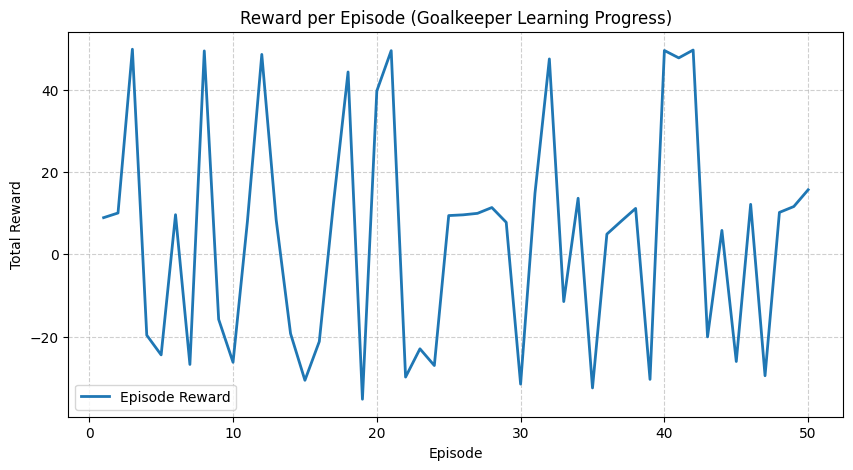

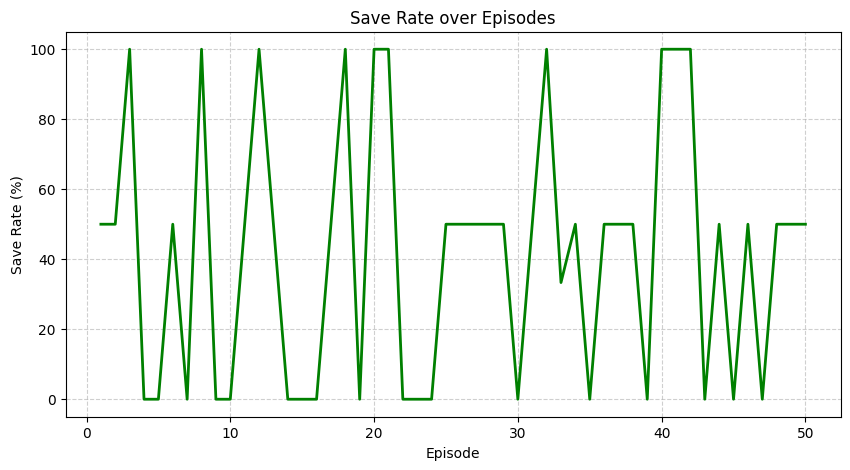

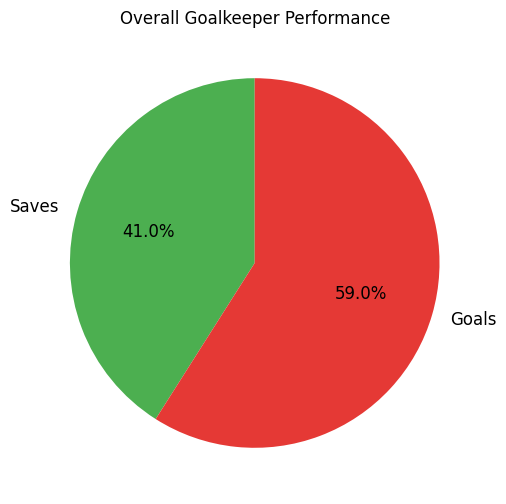

RL GOALKEEPER TRAINING - FIXED VERSION
Fixes:
  ✓ Goalkeeper no longer drifts from goal line
  ✓ Stats accumulate across entire training
  ✓ Strong X-axis lock to prevent horizontal drift
  ✓ Cumulative reward, saves, goals, and save% display

SHOT! Target Y: 439, GK Y: 415, Goal Center: 400
SHOT! Target Y: 358, GK Y: 390, Goal Center: 400
Episode    0 | Avg Reward:   12.17 | Cumulative Save%:  50.0% | Loss: 0.4217 | Total: 1/2 saves
SHOT! Target Y: 441, GK Y: 415, Goal Center: 400
SHOT! Target Y: 356, GK Y: 388, Goal Center: 400
SHOT! Target Y: 426, GK Y: 415, Goal Center: 400
SHOT! Target Y: 368, GK Y: 395, Goal Center: 400
SHOT! Target Y: 428, GK Y: 415, Goal Center: 400
SHOT! Target Y: 437, GK Y: 395, Goal Center: 400
SHOT! Target Y: 362, GK Y: 415, Goal Center: 400
SHOT! Target Y: 436, GK Y: 394, Goal Center: 400
SHOT! Target Y: 365, GK Y: 415, Goal Center: 400
SHOT! Target Y: 436, GK Y: 406, Goal Center: 400
SHOT! Target Y: 438, GK Y: 415, Goal Center: 400
SHOT! Target Y: 441, GK

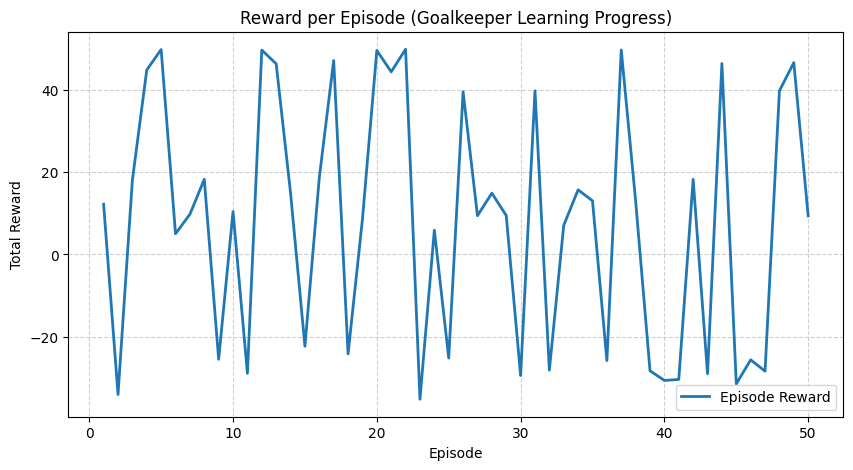

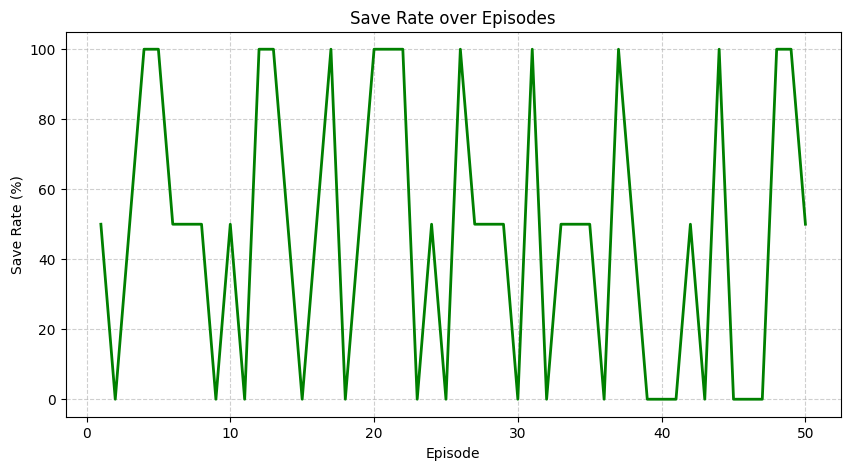

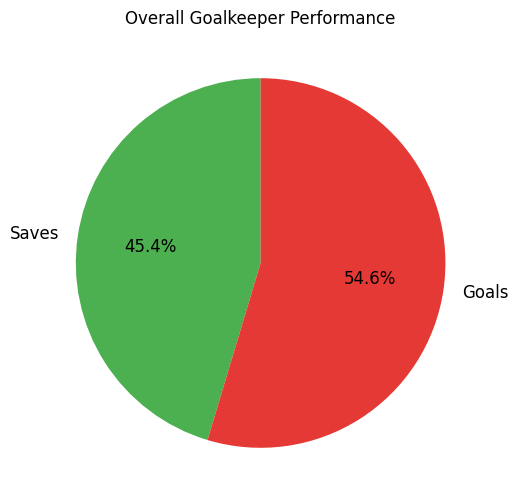


TRAINING COMPLETE!

To save the trained model:
  torch.save(trained_agent.policy.state_dict(), 'goalkeeper_model.pth')

To load the model later:
  agent = PPOAgent(state_dim=16)
  agent.policy.load_state_dict(torch.load('goalkeeper_model.pth'))


In [7]:
import pygame
import math
import random
import numpy as np
from enum import Enum
import torch
import torch.nn as nn
import torch.optim as optim

# --- Game Constants ---
FIELD_WIDTH = 1200
FIELD_HEIGHT = 800
GOALKEEPER_SIZE = 25  # Reduced from 35
ATTACKER_SIZE = 25    # Reduced from 35
BALL_RADIUS = 8       # Reduced from 10
GOAL_WIDTH = 180
GOAL_HEIGHT = 120
PENALTY_AREA_WIDTH = 165
PENALTY_AREA_HEIGHT = 400
SIX_YARD_WIDTH = 55
SIX_YARD_HEIGHT = 200
ATTACKER_SPEED = 3.5
CENTER_CIRCLE_RADIUS = 90
BALL_SPEED = 8
KICK_POWER = 13
BALL_FRICTION = 0.96

# --- Enhanced Colors ---
GRASS_BASE = (46, 155, 76)
GRASS_STRIPE_LIGHT = (52, 168, 83)
GRASS_STRIPE_DARK = (41, 142, 68)
LINE_WHITE = (255, 255, 255)
LINE_YELLOW = (255, 220, 100)
GOAL_WHITE = (240, 240, 240)
GOALKEEPER_BLUE = (30, 144, 255)
ATTACKER_RED = (220, 20, 60)
BALL_WHITE = (255, 255, 255)
SKIN_TONE = (255, 220, 177)

class GoalkeeperState(Enum):
    IDLE = 0
    TRACKING = 1
    READY = 2
    DIVING = 3
    RECOVERING = 4
    CAUGHT = 5
    THROWING = 6

class DiveDirection(Enum):
    NONE = 0
    LEFT = 1
    RIGHT = 2
    DOWN = 3

# ============================================
# PITCH DRAWING FUNCTIONS
# ============================================

def draw_pitch(surface):
    """Draw a realistic mobile game-style pitch"""
    surface.fill(GRASS_BASE)
    
    # Draw grass stripes
    stripe_width = 60
    for i in range(0, FIELD_WIDTH, stripe_width):
        if i % (stripe_width * 2) == 0:
            pygame.draw.rect(surface, GRASS_STRIPE_LIGHT, (i, 0, stripe_width, FIELD_HEIGHT))
        else:
            pygame.draw.rect(surface, GRASS_STRIPE_DARK, (i, 0, stripe_width, FIELD_HEIGHT))
    
    # Boundary lines
    pygame.draw.rect(surface, LINE_WHITE, (5, 5, FIELD_WIDTH - 10, FIELD_HEIGHT - 10), 4)
    
    # Center line
    pygame.draw.line(surface, LINE_WHITE, (FIELD_WIDTH // 2, 5), (FIELD_WIDTH // 2, FIELD_HEIGHT - 5), 4)
    
    # Center circle
    center_x = FIELD_WIDTH // 2
    center_y = FIELD_HEIGHT // 2
    pygame.draw.circle(surface, LINE_WHITE, (center_x, center_y), CENTER_CIRCLE_RADIUS, 4)
    pygame.draw.circle(surface, LINE_WHITE, (center_x, center_y), 8, 0)
    
    # Penalty area (right side)
    penalty_x = FIELD_WIDTH - PENALTY_AREA_WIDTH
    penalty_y = (FIELD_HEIGHT - PENALTY_AREA_HEIGHT) // 2
    pygame.draw.rect(surface, LINE_WHITE, (penalty_x, penalty_y, PENALTY_AREA_WIDTH - 5, PENALTY_AREA_HEIGHT), 4)
    
    # Six-yard box
    six_yard_x = FIELD_WIDTH - SIX_YARD_WIDTH
    six_yard_y = (FIELD_HEIGHT - SIX_YARD_HEIGHT) // 2
    pygame.draw.rect(surface, LINE_WHITE, (six_yard_x, six_yard_y, SIX_YARD_WIDTH - 5, SIX_YARD_HEIGHT), 4)
    
    # Penalty spot
    penalty_spot_x = FIELD_WIDTH - 110
    penalty_spot_y = FIELD_HEIGHT // 2
    pygame.draw.circle(surface, LINE_WHITE, (penalty_spot_x, penalty_spot_y), 6, 0)
    
    # Penalty arc
    for angle in range(-50, 51, 2):
        rad = math.radians(angle)
        arc_radius = 100
        x1 = penalty_spot_x + arc_radius * math.cos(rad)
        y1 = penalty_spot_y + arc_radius * math.sin(rad)
        if x1 <= FIELD_WIDTH - PENALTY_AREA_WIDTH:
            pygame.draw.circle(surface, LINE_WHITE, (int(x1), int(y1)), 2)
    
    # Corner arcs
    corner_radius = 25
    pygame.draw.arc(surface, LINE_WHITE, 
                    (FIELD_WIDTH - corner_radius * 2 - 5, FIELD_HEIGHT - corner_radius * 2 - 5, 
                     corner_radius * 2, corner_radius * 2), 
                    math.pi, math.pi * 1.5, 4)
    pygame.draw.arc(surface, LINE_WHITE, 
                    (FIELD_WIDTH - corner_radius * 2 - 5, 5, 
                     corner_radius * 2, corner_radius * 2), 
                    math.pi * 1.5, math.pi * 2, 4)

def draw_goal_3d(surface, x, y, width, height):
    """Draw a 3D-looking goal"""
    shadow_offset = 8
    pygame.draw.rect(surface, (40, 40, 40), 
                     (x + shadow_offset, y + shadow_offset, width, height), 0)
    
    net_color = (180, 180, 180)
    pygame.draw.rect(surface, net_color, (x, y, width, height), 0)
    
    # Net pattern
    net_spacing = 15
    for i in range(0, height, net_spacing):
        pygame.draw.line(surface, (160, 160, 160), (x, y + i), (x + width, y + i), 1)
    for i in range(0, width, net_spacing):
        pygame.draw.line(surface, (160, 160, 160), (x + i, y), (x + i, y + height), 1)
    
    # Goal posts
    post_width = 8
    pygame.draw.rect(surface, (200, 200, 200), (x - post_width, y, post_width, height))
    pygame.draw.rect(surface, LINE_WHITE, (x - post_width + 2, y, post_width - 4, height))
    pygame.draw.rect(surface, (200, 200, 200), (x - post_width, y - post_width, width + post_width, post_width))
    pygame.draw.rect(surface, LINE_WHITE, (x - post_width + 2, y - post_width + 2, width + post_width - 4, post_width - 4))
    pygame.draw.rect(surface, (200, 200, 200), (x - post_width, y + height, width + post_width, post_width))
    pygame.draw.rect(surface, LINE_WHITE, (x - post_width + 2, y + height, width + post_width - 4, post_width - 2))

def draw_player_model(surface, x, y, size, color, number, facing_right=True, diving=False, has_ball=False):
    """Draw a detailed player model with body parts"""
    # Shadow
    shadow_width = size if not diving else size * 1.8
    pygame.draw.ellipse(surface, (40, 40, 40), 
                       (int(x - shadow_width//2), int(y + size//2 - 3),
                        int(shadow_width), 12))
    
    body_color = color
    outline_color = tuple(max(0, c - 60) for c in color)
    
    if diving:
        # Diving pose
        # Body (stretched horizontally)
        body_width = size * 1.5
        body_height = size * 0.6
        body_x = x - body_width // 2
        body_y = y - body_height // 2
        pygame.draw.ellipse(surface, outline_color, 
                          (int(body_x - 2), int(body_y - 2), int(body_width + 4), int(body_height + 4)))
        pygame.draw.ellipse(surface, body_color, 
                          (int(body_x), int(body_y), int(body_width), int(body_height)))
        
        # Head
        head_radius = size // 4
        head_x = x + (body_width // 3 if facing_right else -body_width // 3)
        head_y = y - head_radius
        pygame.draw.circle(surface, SKIN_TONE, (int(head_x), int(head_y)), head_radius)
        pygame.draw.circle(surface, (0, 0, 0), (int(head_x), int(head_y)), head_radius, 1)
        
        # Arms stretched
        arm_offset_y = 3
        pygame.draw.line(surface, SKIN_TONE, 
                        (int(x - body_width//2), int(y + arm_offset_y)),
                        (int(x - body_width//2 - 15), int(y + arm_offset_y - 8)), 6)
        pygame.draw.line(surface, SKIN_TONE, 
                        (int(x + body_width//2), int(y + arm_offset_y)),
                        (int(x + body_width//2 + 15), int(y + arm_offset_y - 8)), 6)
        
        # Legs stretched
        pygame.draw.line(surface, body_color, 
                        (int(x), int(y + 5)),
                        (int(x - 18), int(y + 12)), 7)
        pygame.draw.line(surface, body_color, 
                        (int(x), int(y + 5)),
                        (int(x + 18), int(y + 12)), 7)
    else:
        # Standing pose
        # Head
        head_radius = size // 3
        pygame.draw.circle(surface, SKIN_TONE, (int(x), int(y - size//3)), head_radius)
        pygame.draw.circle(surface, (0, 0, 0), (int(x), int(y - size//3)), head_radius, 2)
        
        # Eyes
        eye_offset = head_radius // 3
        pygame.draw.circle(surface, (0, 0, 0), 
                         (int(x - eye_offset), int(y - size//3 - 2)), 2)
        pygame.draw.circle(surface, (0, 0, 0), 
                         (int(x + eye_offset), int(y - size//3 - 2)), 2)
        
        # Body (torso)
        body_width = size * 0.8
        body_height = size * 0.7
        pygame.draw.ellipse(surface, outline_color,
                          (int(x - body_width//2 - 2), int(y - 2), 
                           int(body_width + 4), int(body_height + 4)))
        pygame.draw.ellipse(surface, body_color,
                          (int(x - body_width//2), int(y), 
                           int(body_width), int(body_height)))
        
        # Arms
        arm_offset = body_width // 2
        arm_length = size // 2
        pygame.draw.line(surface, body_color, 
                        (int(x - arm_offset), int(y + 5)),
                        (int(x - arm_offset - 5), int(y + arm_length)), 6)
        pygame.draw.line(surface, body_color, 
                        (int(x + arm_offset), int(y + 5)),
                        (int(x + arm_offset + 5), int(y + arm_length)), 6)
        
        # Hands
        pygame.draw.circle(surface, SKIN_TONE, 
                         (int(x - arm_offset - 5), int(y + arm_length)), 5)
        pygame.draw.circle(surface, SKIN_TONE, 
                         (int(x + arm_offset + 5), int(y + arm_length)), 5)
        
        # Legs
        leg_offset = 8
        leg_length = size // 2 + 2
        pygame.draw.line(surface, body_color, 
                        (int(x - leg_offset), int(y + body_height - 5)),
                        (int(x - leg_offset - 3), int(y + body_height + leg_length)), 7)
        pygame.draw.line(surface, body_color, 
                        (int(x + leg_offset), int(y + body_height - 5)),
                        (int(x + leg_offset + 3), int(y + body_height + leg_length)), 7)
        
        # Feet (boots)
        pygame.draw.circle(surface, (40, 40, 40), 
                         (int(x - leg_offset - 3), int(y + body_height + leg_length)), 5)
        pygame.draw.circle(surface, (40, 40, 40), 
                         (int(x + leg_offset + 3), int(y + body_height + leg_length)), 5)
    
    # Jersey number
    font = pygame.font.Font(None, 22)
    number_text = font.render(str(number), True, LINE_WHITE)
    text_rect = number_text.get_rect(center=(int(x), int(y + 5)))
    
    bg_rect = text_rect.inflate(8, 6)
    pygame.draw.rect(surface, (0, 0, 0), bg_rect, border_radius=3)
    surface.blit(number_text, text_rect)
    
    # Ball at feet indicator (only for standing players with ball)
    if has_ball and not diving:
        # Draw a small circle near the feet
        ball_x = x + 18
        ball_y = y + size//2 + leg_length - 3
        pygame.draw.circle(surface, (255, 200, 0), (int(ball_x), int(ball_y)), 3)
        pygame.draw.circle(surface, (255, 255, 100), (int(ball_x), int(ball_y)), 5, 2)

# ============================================
# NEURAL NETWORK
# ============================================

class ActorCritic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(ActorCritic, self).__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(state_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        
        self.actor_movement = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )
        
        self.actor_dive = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )
        
        self.critic = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, state):
        features = self.shared(state)
        movement = torch.tanh(self.actor_movement(features))
        dive_logits = self.actor_dive(features)
        value = self.critic(features)
        return movement, dive_logits, value
    
    def get_action(self, state, deterministic=False):
        movement, dive_logits, value = self.forward(state)
        
        if deterministic:
            dive_action = torch.argmax(dive_logits, dim=-1)
        else:
            dive_probs = torch.softmax(dive_logits, dim=-1)
            dive_action = torch.multinomial(dive_probs, 1).squeeze()
        
        return movement, dive_action, value

class PPOAgent:
    def __init__(self, state_dim=16, lr=3e-4, gamma=0.99, eps_clip=0.2, k_epochs=10):
        self.gamma = gamma
        self.eps_clip = eps_clip
        self.k_epochs = k_epochs
        
        self.policy = ActorCritic(state_dim, action_dim=2)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.policy_old = ActorCritic(state_dim, action_dim=2)
        self.policy_old.load_state_dict(self.policy.state_dict())
        
        self.MseLoss = nn.MSELoss()
        
        self.states = []
        self.actions_movement = []
        self.actions_dive = []
        self.rewards = []
        self.is_terminals = []
        self.logprobs = []
        
    def select_action(self, state, training=True):
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            movement, dive_action, _ = self.policy_old.get_action(state_tensor, deterministic=not training)
            
            if training:
                _, dive_logits, _ = self.policy_old(state_tensor)
                dive_probs = torch.softmax(dive_logits, dim=-1)
                logprob = torch.log(dive_probs[0, dive_action] + 1e-10)
                
                self.states.append(state)
                self.actions_movement.append(movement.squeeze().numpy())
                self.actions_dive.append(dive_action.item())
                self.logprobs.append(logprob.item())
            
            return movement.squeeze().numpy(), dive_action.item()
    
    def store_reward(self, reward, done):
        self.rewards.append(reward)
        self.is_terminals.append(done)
    
    def update(self):
        if len(self.states) == 0:
            return 0.0
        
        min_len = min(len(self.states), len(self.actions_movement), len(self.actions_dive), 
                      len(self.rewards), len(self.is_terminals), len(self.logprobs))
        self.states = self.states[:min_len]
        self.actions_movement = self.actions_movement[:min_len]
        self.actions_dive = self.actions_dive[:min_len]
        self.rewards = self.rewards[:min_len]
        self.is_terminals = self.is_terminals[:min_len]
        self.logprobs = self.logprobs[:min_len]

        rewards = []
        discounted_reward = 0
        for reward, is_terminal in zip(reversed(self.rewards), reversed(self.is_terminals)):
            if is_terminal:
                discounted_reward = 0
            discounted_reward = reward + (self.gamma * discounted_reward)
            rewards.insert(0, discounted_reward)
        
        rewards = torch.tensor(rewards, dtype=torch.float32)
        rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-7)
        
        old_states = torch.FloatTensor(np.array(self.states))
        old_actions_dive = torch.LongTensor(self.actions_dive)
        old_logprobs = torch.FloatTensor(self.logprobs)
        
        total_loss = 0
        
        for _ in range(self.k_epochs):
            movement, dive_logits, state_values = self.policy(old_states)
            
            dive_probs = torch.softmax(dive_logits, dim=-1)
            dist = torch.distributions.Categorical(dive_probs)
            dive_logprobs = dist.log_prob(old_actions_dive)
            dist_entropy = dist.entropy()
            
            ratios = torch.exp(dive_logprobs - old_logprobs)
            advantages = rewards - state_values.squeeze().detach()
            
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages
            
            loss = -torch.min(surr1, surr2).mean() + 0.5 * self.MseLoss(state_values.squeeze(), rewards) - 0.01 * dist_entropy.mean()
            
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            
            total_loss += loss.item()
        
        self.policy_old.load_state_dict(self.policy.state_dict())
        
        self.states.clear()
        self.actions_movement.clear()
        self.actions_dive.clear()
        self.rewards.clear()
        self.is_terminals.clear()
        self.logprobs.clear()
        
        return total_loss / self.k_epochs

# ============================================
# RL GOALKEEPER
# ============================================

class RLGoalkeeper:
    def __init__(self, x, y, agent=None):
        self.initial_x = x
        self.initial_y = y
        self.x = x
        self.y = y
        self.size = GOALKEEPER_SIZE
        self.state = GoalkeeperState.IDLE
        self.dive_direction = DiveDirection.NONE
        self.dive_timer = 0
        self.movement_speed = 2.5
        
        self.agent = agent
        self.threat_level = 0
        
        self.rl_action_movement = [0, 0]
        self.rl_action_dive = 0
        
        # For catching and throwing
        self.has_ball = False
        self.catch_timer = 0
        self.throw_timer = 0
        
    def get_state(self, attacker, ball, goal):
        """Enhanced state representation"""
        # Goal positioning
        goal_center_y = goal.y + goal.height / 2
        
        # Ball trajectory prediction
        if ball.is_shot and (abs(ball.dx) > 0.5 or abs(ball.dy) > 0.5):
            # Predict where ball will be
            future_time = 20
            predicted_x = ball.x + ball.dx * future_time
            predicted_y = ball.y + ball.dy * future_time
        else:
            predicted_x = ball.x
            predicted_y = ball.y
        
        state = [
            (self.x - self.initial_x) / 100,  # Displacement from home
            (self.y - self.initial_y) / 100,
            
            ball.x / FIELD_WIDTH,
            ball.y / FIELD_HEIGHT,
            ball.dx / KICK_POWER,
            ball.dy / KICK_POWER,
            float(ball.is_shot),
            
            attacker.x / FIELD_WIDTH,
            attacker.y / FIELD_HEIGHT,
            attacker.dx / ATTACKER_SPEED,
            attacker.dy / ATTACKER_SPEED,
            float(attacker.has_ball),
            
            (predicted_x - self.x) / FIELD_WIDTH,
            (predicted_y - self.y) / FIELD_HEIGHT,
            
            math.sqrt((ball.x - self.x)**2 + (ball.y - self.y)**2) / FIELD_WIDTH,
            self.threat_level
        ]
        return np.array(state, dtype=np.float32)
    
    def update(self, attacker, ball, goal, training=True):
        """Update with FIXED positioning logic to prevent drifting"""
        # Calculate threat
        goal_center_x = goal.x
        goal_center_y = goal.y + goal.height / 2
        
        if ball.is_shot:
            threat_x = ball.x
            threat_y = ball.y
        else:
            threat_x = attacker.x
            threat_y = attacker.y
        
        distance_to_threat = math.sqrt((threat_x - goal_center_x)**2 + (threat_y - goal_center_y)**2)
        
        if distance_to_threat < 500:
            self.threat_level = min(1.0, (500 - distance_to_threat) / 500)
        else:
            self.threat_level = 0
        
        # Get RL action
        if self.agent and self.state in [GoalkeeperState.IDLE, GoalkeeperState.TRACKING, GoalkeeperState.READY]:
            state = self.get_state(attacker, ball, goal)
            movement, dive_action = self.agent.select_action(state, training=training)
            self.rl_action_movement = movement
            self.rl_action_dive = dive_action
        
        # Execute actions based on state
        if self.state in [GoalkeeperState.IDLE, GoalkeeperState.TRACKING, GoalkeeperState.READY]:
            # Update state
            if self.threat_level > 0.7:
                self.state = GoalkeeperState.READY
            elif self.threat_level > 0.3:
                self.state = GoalkeeperState.TRACKING
            else:
                self.state = GoalkeeperState.IDLE
            
            # FIXED: Much stronger home position keeping
            # Only allow vertical movement, lock horizontal to goal line
            target_y = self.initial_y
            
            # Adjust Y based on ball/attacker position
            if ball.is_shot:
                target_y = ball.y
            else:
                target_y = attacker.y
            
            # Clamp target_y to goal bounds
            target_y = max(goal.y + 20, min(goal.y + goal.height - 20, target_y))
            
            # FIXED: Only use RL action for Y movement, lock X to initial position
            move_y = self.rl_action_movement[1] * self.movement_speed
            
            # Strong Y position adjustment towards target
            y_pull = (target_y - self.y) * 0.25
            
            # FIXED: Strong X lock to initial position - this prevents drifting!
            x_correction = (self.initial_x - self.x) * 0.5  # Strong pull back
            
            # Apply movements
            self.x += x_correction  # Strong horizontal lock
            self.y += move_y + y_pull
            
            # FIXED: Strict boundaries - especially on X axis
            self.x = max(self.initial_x - 5, min(self.initial_x + 5, self.x))  # Very tight X constraint
            self.y = max(goal.y + 20, min(goal.y + goal.height - 20, self.y))
            
            # Check for dive
            if self.rl_action_dive > 0 and (ball.is_shot or self.threat_level > 0.8):
                self.dive_direction = DiveDirection(self.rl_action_dive)
                self.state = GoalkeeperState.DIVING
                self.dive_timer = 20
        
        elif self.state == GoalkeeperState.DIVING:
            self.dive_timer -= 1
            
            if self.dive_direction == DiveDirection.LEFT:
                self.y -= 5
            elif self.dive_direction == DiveDirection.RIGHT:
                self.y += 5
            elif self.dive_direction == DiveDirection.DOWN:
                self.x += 3
            
            if self.dive_timer <= 0:
                self.state = GoalkeeperState.RECOVERING
                self.dive_timer = 25
        
        elif self.state == GoalkeeperState.RECOVERING:
            self.dive_timer -= 1
            
            # Return to home - FIXED with stronger pull
            dx = self.initial_x - self.x
            dy = self.initial_y - self.y
            self.x += dx * 0.3  # Increased from 0.15
            self.y += dy * 0.3  # Increased from 0.15
            
            if self.dive_timer <= 0:
                self.state = GoalkeeperState.IDLE
                self.dive_direction = DiveDirection.NONE
                # FIXED: Force exact position
                self.x = self.initial_x
                self.y = self.initial_y
        
        elif self.state == GoalkeeperState.CAUGHT:
            # Hold ball for a moment
            self.catch_timer += 1
            
            # Ball follows goalkeeper
            ball.x = self.x
            ball.y = self.y - 10
            ball.dx = 0
            ball.dy = 0
            ball.is_shot = False
            
            # After holding, prepare to throw
            if self.catch_timer > 40:
                self.state = GoalkeeperState.THROWING
                self.throw_timer = 0
                self.catch_timer = 0
        
        elif self.state == GoalkeeperState.THROWING:
            self.throw_timer += 1
            
            # Hold ball during throw animation
            ball.x = self.x - 15
            ball.y = self.y - 5
            ball.dx = 0
            ball.dy = 0
            
            # Throw the ball
            if self.throw_timer > 20:
                self.throw_ball(ball, attacker)
                self.has_ball = False
                self.state = GoalkeeperState.IDLE
                self.throw_timer = 0
    
    def throw_ball(self, ball, attacker):
        """Throw ball towards attacker or safe area"""
        # Throw to the side or towards attacker's area
        target_x = FIELD_WIDTH // 2
        target_y = FIELD_HEIGHT // 2 + random.randint(-100, 100)
        
        dx = target_x - ball.x
        dy = target_y - ball.y
        distance = math.sqrt(dx*dx + dy*dy)
        
        if distance > 0:
            throw_power = 8
            ball.dx = (dx / distance) * throw_power
            ball.dy = (dy / distance) * throw_power
            ball.is_shot = False
    
    def check_save(self, ball):
        """Check if goalkeeper saved the ball and catch it"""
        distance = math.sqrt((ball.x - self.x)**2 + (ball.y - self.y)**2)
        save_radius = self.size // 2 + ball.radius + 10
        
        if self.state == GoalkeeperState.DIVING:
            save_radius += 20
        
        if distance < save_radius and ball.is_shot:
            # Catch the ball
            self.has_ball = True
            self.state = GoalkeeperState.CAUGHT
            self.catch_timer = 0
            return True
        
        return False
    
    def draw(self, surface):
        if self.state == GoalkeeperState.READY:
            color = (255, 120, 120)
        elif self.state == GoalkeeperState.DIVING:
            color = (255, 50, 50)
        elif self.state == GoalkeeperState.TRACKING:
            color = (120, 255, 120)
        elif self.state == GoalkeeperState.RECOVERING:
            color = (200, 200, 255)
        elif self.state == GoalkeeperState.CAUGHT:
            color = (100, 255, 255)
        elif self.state == GoalkeeperState.THROWING:
            color = (255, 200, 100)
        else:
            color = GOALKEEPER_BLUE
        
        diving = (self.state == GoalkeeperState.DIVING)
        draw_player_model(surface, self.x, self.y, self.size, color, "1", True, diving, self.has_ball)

# ============================================
# RL ATTACKER
# ============================================

class RLAttacker:
    def __init__(self, x, y, agent=None):
        self.x = x
        self.y = y
        self.size = ATTACKER_SIZE
        self.dx = 0
        self.dy = 0
        self.has_ball = True
        self.agent = agent
        self.shot_timer = 0
        self.movement_timer = 0
        
    def get_state(self, ball, goal, goalkeeper):
        """State for attacker"""
        goal_center_y = goal.y + goal.height / 2
        
        state = [
            self.x / FIELD_WIDTH,
            self.y / FIELD_HEIGHT,
            self.dx / ATTACKER_SPEED,
            self.dy / ATTACKER_SPEED,
            
            ball.x / FIELD_WIDTH,
            ball.y / FIELD_HEIGHT,
            float(self.has_ball),
            
            goal.x / FIELD_WIDTH,
            goal_center_y / FIELD_HEIGHT,
            
            goalkeeper.x / FIELD_WIDTH,
            goalkeeper.y / FIELD_HEIGHT,
            
            math.sqrt((self.x - ball.x)**2 + (self.y - ball.y)**2) / FIELD_WIDTH,
            math.sqrt((self.x - goal.x)**2 + (self.y - goal_center_y)**2) / FIELD_WIDTH,
            
            # Goalkeeper positioning relative to goal
            (goalkeeper.y - goal_center_y) / goal.height,
            
            self.shot_timer / 200.0,
            float(goalkeeper.state == GoalkeeperState.DIVING)
        ]
        return np.array(state, dtype=np.float32)
    
    def update(self, ball, goal, goalkeeper, training=True):
        self.shot_timer += 1
        self.movement_timer += 1
        
        # Intelligent positioning
        goal_center_y = goal.y + goal.height / 2
        
        # Find gaps in goal based on goalkeeper position
        goalkeeper_y = goalkeeper.y
        
        # Determine target based on goalkeeper position
        if goalkeeper_y > goal_center_y + 15:
            # GK is high, target low
            target_y = goal.y + 40
        elif goalkeeper_y < goal_center_y - 15:
            # GK is low, target high  
            target_y = goal.y + goal.height - 40
        else:
            # GK centered, pick random side
            if self.movement_timer % 200 < 100:
                target_y = goal.y + 40
            else:
                target_y = goal.y + goal.height - 40
        
        # Optimal shooting distance - closer to goal
        target_x = FIELD_WIDTH - 220
        
        # Movement toward target position
        dx = target_x - self.x
        dy = target_y - self.y
        dist = math.sqrt(dx*dx + dy*dy)
        
        if dist > 15:
            speed = ATTACKER_SPEED
            self.dx = (dx / dist) * speed
            self.dy = (dy / dist) * speed
            self.x += self.dx
            self.y += self.dy
        else:
            self.dx *= 0.5
            self.dy *= 0.5
        
        # Boundaries
        self.x = max(50, min(FIELD_WIDTH - 120, self.x))
        self.y = max(50, min(FIELD_HEIGHT - 50, self.y))
        
        # Shooting conditions - more aggressive
        in_shooting_range = (self.x > FIELD_WIDTH - 300)
        has_waited_enough = (self.shot_timer > 100)
        in_good_position = (dist < 40)
        
        should_shoot = (
            self.has_ball and 
            in_shooting_range and
            has_waited_enough and
            in_good_position
        )
        
        # Also shoot if very close regardless of timer
        if self.has_ball and self.x > FIELD_WIDTH - 200 and self.shot_timer > 50:
            should_shoot = True
        
        if should_shoot:
            self.shoot(ball, goal, goalkeeper)
            self.shot_timer = 0
    
    def shoot(self, ball, goal, goalkeeper):
        """Intelligent shooting - aim away from goalkeeper"""
        if not self.has_ball:
            return
        
        goal_center_y = goal.y + goal.height / 2
        goalkeeper_y = goalkeeper.y
        
        # Calculate open areas of goal
        gap_threshold = 25
        
        # Aim at the side with most space from goalkeeper
        if goalkeeper_y > goal_center_y + gap_threshold:
            # Goalkeeper is high, shoot low (bottom of goal)
            target_y = goal.y + 25
        elif goalkeeper_y < goal_center_y - gap_threshold:
            # Goalkeeper is low, shoot high (top of goal)
            target_y = goal.y + goal.height - 25
        else:
            # Goalkeeper is centered, pick a corner
            if abs(goalkeeper_y - goal_center_y) < 15:
                # Very centered, pick random corner
                if random.random() > 0.5:
                    target_y = goal.y + 25
                else:
                    target_y = goal.y + goal.height - 25
            else:
                # Shoot to the side opposite of goalkeeper
                if goalkeeper_y > goal_center_y:
                    target_y = goal.y + 25
                else:
                    target_y = goal.y + goal.height - 25
        
        # Add slight randomness for realism
        target_y += random.uniform(-10, 10)
        target_x = goal.x - 5
        
        # Calculate shot vector
        dx = target_x - ball.x
        dy = target_y - ball.y
        distance = math.sqrt(dx*dx + dy*dy)
        
        if distance > 0:
            # Use full power for better shooting
            power = KICK_POWER * 1.1
            ball.dx = (dx / distance) * power
            ball.dy = (dy / distance) * power
            ball.is_shot = True
            self.has_ball = False
            
            # Debug print
            print(f"SHOT! Target Y: {target_y:.0f}, GK Y: {goalkeeper_y:.0f}, Goal Center: {goal_center_y:.0f}")
    
    def draw(self, surface):
        color = ATTACKER_RED if self.has_ball else (140, 140, 140)
        draw_player_model(surface, self.x, self.y, self.size, color, "7", True, False, self.has_ball)

# ============================================
# BALL CLASS
# ============================================

class Ball:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.dx = 0
        self.dy = 0
        self.radius = BALL_RADIUS
        self.trail = []
        self.is_shot = False
        
    def update(self, attacker):
        if not self.is_shot and attacker.has_ball:
            # Ball at feet, not in hands
            offset_x = 20
            offset_y = 25  # Lower, at feet level
            self.x = attacker.x + offset_x
            self.y = attacker.y + offset_y
        else:
            self.x += self.dx
            self.y += self.dy
            
            self.dx *= BALL_FRICTION
            self.dy *= BALL_FRICTION
            
            if abs(self.dx) > 1 or abs(self.dy) > 1:
                self.trail.append((self.x, self.y))
                if len(self.trail) > 12:
                    self.trail.pop(0)
            else:
                self.trail = []
            
            # Boundaries
            if self.x - self.radius <= 0 or self.x + self.radius >= FIELD_WIDTH:
                self.dx *= -0.8
                self.x = max(self.radius, min(FIELD_WIDTH - self.radius, self.x))
            if self.y - self.radius <= 0 or self.y + self.radius >= FIELD_HEIGHT:
                self.dy *= -0.8
                self.y = max(self.radius, min(FIELD_HEIGHT - self.radius, self.y))
            
            # Ball stops moving
            if abs(self.dx) < 0.5 and abs(self.dy) < 0.5:
                self.dx = 0
                self.dy = 0
                self.is_shot = False
    
    def reset_to_attacker(self, attacker):
        self.x = attacker.x + 20
        self.y = attacker.y + 25  # At feet level
        self.dx = 0
        self.dy = 0
        self.is_shot = False
        self.trail = []
        attacker.has_ball = True
    
    def draw(self, surface):
        # Trail
        for i, (tx, ty) in enumerate(self.trail):
            alpha = (i + 1) / len(self.trail)
            trail_radius = int(self.radius * alpha * 0.7)
            color_val = int(150 + 105 * alpha)
            pygame.draw.circle(surface, (color_val, color_val, color_val), (int(tx), int(ty)), trail_radius)
        
        # Shadow
        pygame.draw.ellipse(surface, (80, 80, 80), 
                          (int(self.x - self.radius), int(self.y + self.radius - 2),
                           self.radius * 2, 6))
        
        # Ball with highlight
        pygame.draw.circle(surface, (240, 240, 240), (int(self.x), int(self.y)), self.radius)
        pygame.draw.circle(surface, BALL_WHITE, (int(self.x - 2), int(self.y - 2)), self.radius - 2)
        pygame.draw.circle(surface, (0, 0, 0), (int(self.x), int(self.y)), self.radius, 2)
        pygame.draw.circle(surface, (255, 255, 255), (int(self.x - 3), int(self.y - 3)), 3)

# ============================================
# GOAL CLASS
# ============================================

class Goal:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.width = 10
        self.height = GOAL_HEIGHT
        
    def check_goal(self, ball):
        return (ball.x >= self.x - 5 and 
                ball.y >= self.y and 
                ball.y <= self.y + self.height)
    
    def draw(self, surface):
        draw_goal_3d(surface, self.x, self.y, self.width, self.height)

# ============================================
# TRAINING LOOP
# ============================================

def train_goalkeeper(episodes=1000, render=True):
    """Train the goalkeeper using PPO with FIXED cumulative stats"""
    
    if render:
        pygame.init()
        screen = pygame.display.set_mode((FIELD_WIDTH, FIELD_HEIGHT))
        pygame.display.set_caption("RL Goalkeeper Training - Fixed Stats")
        clock = pygame.time.Clock()
    
    # Create RL agent for goalkeeper
    agent = PPOAgent(state_dim=16, lr=2e-4)
    
    # Training stats
    episode_rewards = []
    save_rates = []
    
    # FIXED: Cumulative stats that persist across episodes
    total_saves = 0
    total_goals = 0
    total_shots = 0
    cumulative_reward = 0
    
    for episode in range(episodes):
        # Initialize environment
        goal = Goal(FIELD_WIDTH - 10, (FIELD_HEIGHT - GOAL_HEIGHT) // 2)
        goalkeeper = RLGoalkeeper(FIELD_WIDTH - 40, FIELD_HEIGHT // 2, agent=agent)
        attacker = RLAttacker(250, FIELD_HEIGHT // 2)
        ball = Ball(270, FIELD_HEIGHT // 2)
        
        episode_reward = 0
        episode_saves = 0
        episode_goals = 0
        episode_shots = 0
        steps = 0
        max_steps = 600
        
        done = False
        
        while not done and steps < max_steps:
            steps += 1
            
            # Update game state
            attacker.update(ball, goal, goalkeeper, training=True)
            ball.update(attacker)
            goalkeeper.update(attacker, ball, goal, training=True)
            
            # Calculate reward
            reward = 0
            
            # Check for save
            if ball.is_shot and goalkeeper.check_save(ball):
                reward += 15.0
                episode_saves += 1
                episode_shots += 1
                
                # FIXED: Update cumulative stats immediately
                total_saves += 1
                total_shots += 1
                
                # Bonus for diving save
                if goalkeeper.state == GoalkeeperState.DIVING:
                    reward += 5.0
            
            # Check for goal
            if ball.is_shot and goal.check_goal(ball):
                reward -= 20.0
                episode_goals += 1
                episode_shots += 1
                
                # FIXED: Update cumulative stats immediately
                total_goals += 1
                total_shots += 1
                
                # Reset after goal
                ball.reset_to_attacker(attacker)
                attacker.x = 250 + random.randint(-80, 80)
                attacker.y = FIELD_HEIGHT // 2 + random.randint(-150, 150)
                attacker.shot_timer = 0
                # Don't set done=True, continue the episode
            
            # Shaping rewards
            if ball.is_shot:
                # Reward for being close to ball trajectory
                dist_to_ball = math.sqrt((ball.x - goalkeeper.x)**2 + (ball.y - goalkeeper.y)**2)
                reward += 0.02 * (1.0 - min(1.0, dist_to_ball / 200))
                
                # Reward for good positioning
                if goalkeeper.state == GoalkeeperState.READY:
                    reward += 0.15
                
                # FIXED: Penalty for drifting from goal line
                dist_from_line = abs(goalkeeper.x - goalkeeper.initial_x)
                if dist_from_line > 15:
                    reward -= 0.2  # Strong penalty for drifting
            else:
                # Reward for staying near home position when no threat
                dist_from_home = math.sqrt((goalkeeper.x - goalkeeper.initial_x)**2 + 
                                          (goalkeeper.y - goalkeeper.initial_y)**2)
                if dist_from_home < 15:
                    reward += 0.05
                else:
                    reward -= 0.02  # Small penalty for being too far
            
            # Check if ball stopped and nobody has it
            if not ball.is_shot and abs(ball.dx) < 0.1 and abs(ball.dy) < 0.1:
                if not attacker.has_ball and not goalkeeper.has_ball:
                    dist_to_attacker = math.sqrt((ball.x - attacker.x)**2 + (ball.y - attacker.y)**2)
                    dist_to_goalkeeper = math.sqrt((ball.x - goalkeeper.x)**2 + (ball.y - goalkeeper.y)**2)
                    
                    # Give ball to closest player
                    if dist_to_attacker < 50 and dist_to_attacker < dist_to_goalkeeper:
                        ball.reset_to_attacker(attacker)
                        attacker.shot_timer = 0
            
            # Out of bounds
            if ball.x < -100 or ball.x > FIELD_WIDTH + 100 or ball.y < -100 or ball.y > FIELD_HEIGHT + 100:
                ball.reset_to_attacker(attacker)
                attacker.x = 250 + random.randint(-80, 80)
                attacker.y = FIELD_HEIGHT // 2 + random.randint(-150, 150)
                attacker.shot_timer = 0
            
            episode_reward += reward
            cumulative_reward += reward  # FIXED: Track cumulative reward
            agent.store_reward(reward, done)
            
            # Render
            if render and episode % 5 == 0:
                # Draw pitch
                draw_pitch(screen)
                
                # Draw game elements
                goal.draw(screen)
                
                # Draw trajectory prediction line when ball is shot
                if ball.is_shot and (abs(ball.dx) > 1 or abs(ball.dy) > 1):
                    future_positions = []
                    temp_x, temp_y = ball.x, ball.y
                    temp_dx, temp_dy = ball.dx, ball.dy
                    for _ in range(15):
                        temp_x += temp_dx
                        temp_y += temp_dy
                        temp_dx *= BALL_FRICTION
                        temp_dy *= BALL_FRICTION
                        future_positions.append((int(temp_x), int(temp_y)))
                    
                    for i, pos in enumerate(future_positions):
                        alpha = 1.0 - (i / len(future_positions))
                        color_val = int(255 * alpha)
                        pygame.draw.circle(screen, (255, color_val, 0), pos, 3)
                
                attacker.draw(screen)
                ball.draw(screen)
                goalkeeper.draw(screen)
                
                # FIXED: Stats bar with cumulative stats
                stats_bg = pygame.Surface((FIELD_WIDTH, 55))
                stats_bg.set_alpha(200)
                stats_bg.fill((20, 20, 20))
                screen.blit(stats_bg, (0, 0))
                
                font_large = pygame.font.Font(None, 32)
                font_small = pygame.font.Font(None, 24)
                
                episode_text = font_large.render(f"Episode: {episode}", True, LINE_YELLOW)
                screen.blit(episode_text, (15, 8))
                
                # FIXED: Show cumulative reward
                reward_text = font_small.render(f"Total Reward: {cumulative_reward:.0f}", True, LINE_WHITE)
                screen.blit(reward_text, (220, 14))
                
                # FIXED: Show cumulative saves
                saves_text = font_small.render(f"Saves: {total_saves}", True, (100, 255, 100))
                screen.blit(saves_text, (430, 14))
                
                # FIXED: Show cumulative goals
                goals_text = font_small.render(f"Goals: {total_goals}", True, (255, 100, 100))
                screen.blit(goals_text, (550, 14))
                
                state_text = font_small.render(f"GK: {goalkeeper.state.name}", True, (150, 200, 255))
                screen.blit(state_text, (680, 14))
                
                threat_text = font_small.render(f"Threat: {goalkeeper.threat_level:.2f}", True, (255, 150, 50))
                screen.blit(threat_text, (880, 14))
                
                # FIXED: Show cumulative save percentage
                if total_shots > 0:
                    save_pct = (total_saves / total_shots) * 100
                    pct_text = font_small.render(f"Save%: {save_pct:.1f}%", True, (200, 200, 255))
                    screen.blit(pct_text, (1050, 14))
                
                pygame.display.flip()
                clock.tick(60)
                
                # Handle events
                for event in pygame.event.get():
                    if event.type == pygame.QUIT:
                        pygame.quit()
                        return agent
        
        # Update policy
        loss = agent.update()
        
        # Track statistics
        episode_rewards.append(episode_reward)
        if episode_shots > 0:
            save_rates.append(episode_saves / episode_shots * 100)
        
        # Print progress
        if episode % 10 == 0:
            avg_reward = np.mean(episode_rewards[-10:]) if episode_rewards else 0
            avg_save_rate = np.mean(save_rates[-10:]) if save_rates else 0
            cumulative_save_pct = (total_saves / total_shots * 100) if total_shots > 0 else 0
            print(f"Episode {episode:4d} | Avg Reward: {avg_reward:7.2f} | "
                  f"Cumulative Save%: {cumulative_save_pct:5.1f}% | Loss: {loss:.4f} | "
                  f"Total: {total_saves}/{total_shots} saves")
    
    if render:
        pygame.quit()
    
    return agent, episode_rewards, save_rates, total_saves, total_goals
import matplotlib.pyplot as plt
import numpy as np

def plot_training_results(episode_rewards, save_rates, total_saves, total_goals):
    episodes = np.arange(1, len(episode_rewards) + 1)
    
    # --- Figure 1: Episode Reward Trend ---
    plt.figure(figsize=(10, 5))
    plt.plot(episodes, episode_rewards, label="Episode Reward", linewidth=2)
    plt.title("Reward per Episode (Goalkeeper Learning Progress)")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

    # --- Figure 2: Save Rate Trend ---
    if len(save_rates) > 0:
        plt.figure(figsize=(10, 5))
        plt.plot(np.arange(1, len(save_rates) + 1), save_rates, color='green', linewidth=2)
        plt.title("Save Rate over Episodes")
        plt.xlabel("Episode")
        plt.ylabel("Save Rate (%)")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.show()
    
    # --- Figure 3: Final Performance Summary ---
    total_shots = total_saves + total_goals
    if total_shots > 0:
        save_percentage = (total_saves / total_shots) * 100
        goal_percentage = (total_goals / total_shots) * 100

        labels = ['Saves', 'Goals']
        values = [save_percentage, goal_percentage]
        colors = ['#4CAF50', '#E53935']

        plt.figure(figsize=(6, 6))
        plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors,
                startangle=90, textprops={'fontsize': 12})
        plt.title("Overall Goalkeeper Performance")
        plt.show()

# Call after training completes:
# (Make sure you have these lists and counters tracked in your train_goalkeeper() function)
# Run training and get statistics
trained_agent, episode_rewards, save_rates, total_saves, total_goals = train_goalkeeper(episodes=50, render=True)
plot_training_results(episode_rewards, save_rates, total_saves, total_goals)


# ============================================
# MAIN
if __name__ == "__main__":
    print("=" * 60)
    print("RL GOALKEEPER TRAINING - FIXED VERSION")
    print("=" * 60)
    print("Fixes:")
    print("  ✓ Goalkeeper no longer drifts from goal line")
    print("  ✓ Stats accumulate across entire training")
    print("  ✓ Strong X-axis lock to prevent horizontal drift")
    print("  ✓ Cumulative reward, saves, goals, and save% display")
    print("=" * 60)
    print()
    
    trained_agent, episode_rewards, save_rates, total_saves, total_goals = train_goalkeeper(episodes=50, render=True)
    plot_training_results(episode_rewards, save_rates, total_saves, total_goals)
    
    print("\n" + "=" * 60)
    print("TRAINING COMPLETE!")
    print("=" * 60)
    print("\nTo save the trained model:")
    print("  torch.save(trained_agent.policy.state_dict(), 'goalkeeper_model.pth')")
    print("\nTo load the model later:")
    print("  agent = PPOAgent(state_dim=16)")
    print("  agent.policy.load_state_dict(torch.load('goalkeeper_model.pth'))")
    print("=" * 60)